<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week4_Day2_ExercisesXPGold_KMeans_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP Gold - K-means from scratch

## What you will create
- A K-means implementation in pure NumPy.
- Scatter plots of clusters and centroid convergence.
- A report with cluster assignments per point.
- A random centroid initializer to study initialization impact.

## What you will learn
- Euclidean distance and closest-centroid assignment.
- How centroid updates reduce within-cluster variance.
- Why initialization matters and how to evaluate runs.


## Task 1 - Load and visualize the dataset
Dataset: `ex7data2.mat` contains an array `X` of shape (m, 2).

- Load with `scipy.io.loadmat`
- Inspect shape and preview first rows
- Scatter plot of points

Shape of X: (300, 2)
[[1.84207953 4.6075716 ]
 [5.65858312 4.79996405]
 [6.35257892 3.2908545 ]
 [2.90401653 4.61220411]
 [3.23197916 4.93989405]]


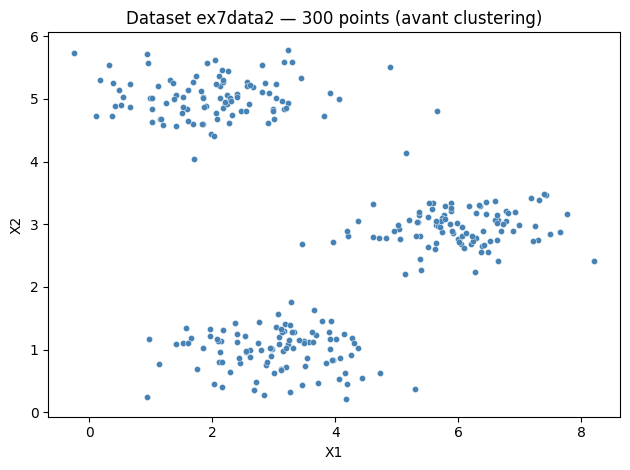

In [4]:
# TODO: load X from the .mat file
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import urllib.request

# Téléchargement du fichier .mat directement depuis GitHub
url = 'https://raw.githubusercontent.com/krasserm/machine-learning-notebooks/master/data/ml-ex7/ex7data2.mat'
urllib.request.urlretrieve(url, 'ex7data2.mat')

# loadmat() charge le fichier .mat (format MATLAB) et retourne un dictionnaire.
# Chaque clé correspond à une variable sauvegardée dans le fichier.
data = loadmat('ex7data2.mat')

# On extrait le tableau numpy X depuis le dictionnaire.
# X contient 300 points en 2 dimensions (X1, X2) — pas de labels : c'est du clustering.
X = data['X']

# Affichage de la forme du tableau : (nombre de points, nombre de features)
print('Shape of X:', X.shape)

# Aperçu des 5 premières lignes pour vérifier le chargement
print(X[:5])

# TODO: scatter plot
# Visualisation des 300 points dans l'espace 2D (X1 en abscisse, X2 en ordonnée).
# On ne connaît pas encore les clusters → tous les points sont de la même couleur.
plt.figure()
plt.scatter(X[:, 0], X[:, 1], s=20, color='steelblue', edgecolors='white', linewidths=0.3)
plt.title('Dataset ex7data2 — 300 points (avant clustering)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.tight_layout()
plt.show()

## Task 2 - Finding closest centroids
Implement `find_closest_centroids(X, centroids)`.

- Input: X shape (m, n), centroids shape (K, n)
- Output: idx shape (m,), integer cluster index in [0, K-1] for each point
- Use squared Euclidean distances

Test with initial centroids = `np.array([[3, 3], [6, 2], [8, 5]])` and print the first three indices.

In [7]:
# TODO: implement
def find_closest_centroids(X, centroids):
    """Return idx of shape (m,) with index of closest centroid for each point."""

    # X a la forme (m, n) : m points, n features
    # centroids a la forme (K, n) : K centroïdes, n features
    # On veut calculer la distance entre CHAQUE point et CHAQUE centroïde.

    # X[:, np.newaxis] transforme X en (m, 1, n) pour permettre le broadcasting.
    # centroids a la forme (K, n), donc la soustraction produit (m, K, n) :
    # pour chaque point i et chaque centroïde k, on obtient le vecteur différence.
    # ** 2 élève au carré chaque composante, .sum(axis=2) somme sur les n features
    # → distances a la forme (m, K) : distance au carré de chaque point vers chaque centroïde
    distances = ((X[:, np.newaxis] - centroids) ** 2).sum(axis=2)

    # np.argmin(axis=1) retourne l'indice du centroïde le plus proche (distance minimale)
    # pour chaque point → idx a la forme (m,) avec des valeurs entières dans [0, K-1]
    idx = np.argmin(distances, axis=1)

    return idx

# Test
import numpy as np

# Centroïdes initiaux fournis par l'énoncé : 3 centroïdes en 2D
init_centroids = np.array([[3, 3], [6, 2], [8, 5]], dtype=float)

# On assigne chaque point du dataset au centroïde le plus proche
idx = find_closest_centroids(X, init_centroids)

# Affichage des 3 premiers indices attendus : [0, 2, 1]
print(idx[:3])

[0 2 1]


## Task 3 - Computing centroids
Implement `compute_centroids(X, idx, K)`.

- For each k in 0..K-1 compute the mean of points assigned to k
- Return `centroids` of shape (K, n)
- If a cluster is empty, reinitialize its centroid by sampling a random point from X

In [8]:
# TODO: implement
def compute_centroids(X, idx, K, rng=None):
    m, n = X.shape

    # Tableau de sortie : K centroïdes de dimension n, initialisés à zéro
    new_centroids = np.zeros((K, n), dtype=float)

    # rng (random number generator) : utilisé pour réinitialiser les clusters vides.
    # Si aucun rng n'est fourni, on utilise le générateur par défaut de numpy.
    rng = np.random.default_rng() if rng is None else rng

    for k in range(K):
        # On sélectionne tous les points assignés au cluster k
        # idx == k retourne un masque booléen de forme (m,)
        pts = X[idx == k]

        if pts.shape[0] == 0:
            # Cluster vide : aucun point ne lui a été assigné.
            # On réinitialise le centroïde en tirant un point aléatoire de X
            # pour éviter qu'il reste bloqué à (0, 0) et ne converge plus.
            new_centroids[k] = X[rng.integers(0, m)]
        else:
            # Cas normal : le nouveau centroïde = moyenne de tous les points du cluster.
            # .mean(axis=0) calcule la moyenne colonne par colonne → vecteur de forme (n,)
            new_centroids[k] = pts.mean(axis=0)

    return new_centroids

# Example test
idx_test = find_closest_centroids(X, init_centroids)
print(compute_centroids(X, idx_test, K=3))

[[2.42830111 3.15792418]
 [5.81350331 2.63365645]
 [7.11938687 3.6166844 ]]


## Task 4 - Running K-means
Implement `run_k_means(X, init_centroids, max_iters)`.

- Loop: assign then update
- Keep history of centroids for plotting
- Return final centroids, idx, and history list
- Run for 10 iterations and plot clusters with final centroids

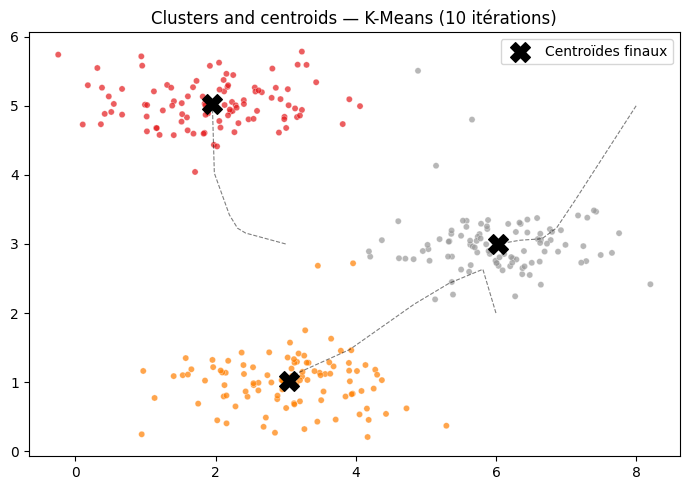

In [9]:
# TODO: implement
def run_k_means(X, init_centroids, max_iters=10, rng=None):
    K = init_centroids.shape[0]

    # On travaille sur une copie pour ne pas modifier les centroïdes initiaux
    centroids = init_centroids.copy().astype(float)

    # history conserve la position des centroïdes à chaque itération
    # → permet de visualiser la trajectoire de convergence après l'entraînement
    history = [centroids.copy()]

    idx = None

    for it in range(max_iters):
        # ÉTAPE 1 — Assignation : chaque point est assigné au centroïde le plus proche
        idx = find_closest_centroids(X, centroids)

        # ÉTAPE 2 — Mise à jour : chaque centroïde se déplace vers la moyenne de son cluster
        centroids = compute_centroids(X, idx, K, rng=rng)

        # On sauvegarde la position des centroïdes après cette itération
        history.append(centroids.copy())

    return centroids, idx, history

# Example run
import matplotlib.pyplot as plt

final_centroids, idx, hist = run_k_means(X, init_centroids, max_iters=10)

plt.figure(figsize=(7, 5))

# Scatter des points colorés par cluster (c=idx donne une couleur par valeur de cluster)
plt.scatter(X[:, 0], X[:, 1], c=idx, cmap='Set1', s=20, alpha=0.7, edgecolors='white', linewidths=0.3)

# Affichage des centroïdes finaux avec un marqueur 'X' bien visible
plt.scatter(final_centroids[:, 0], final_centroids[:, 1],
            marker='X', s=200, c='black', zorder=5, label='Centroïdes finaux')

# Tracé de la trajectoire de chaque centroïde au fil des itérations
for k in range(init_centroids.shape[0]):
    traj = np.array([h[k] for h in hist])  # position du centroïde k à chaque étape
    plt.plot(traj[:, 0], traj[:, 1], 'k--', linewidth=0.8, alpha=0.5)

plt.title('Clusters and centroids — K-Means (10 itérations)')
plt.legend()
plt.tight_layout()
plt.show()

## Task 5 - Initializing centroids
Implement `init_centroids(X, K, rng)` that picks K distinct random points from X.

Test by printing initial centroids for K = 3.

In [10]:
# TODO: implement
def init_centroids(X, K, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    m = X.shape[0]

    # rng.choice(m, size=K, replace=False) tire K indices DISTINCTS parmi [0, m-1]
    # replace=False garantit qu'on ne choisit jamais deux fois le même point
    # → évite d'avoir deux centroïdes identiques au départ (ce qui bloquerait K-Means)
    idx = rng.choice(m, size=K, replace=False)

    # On retourne les K points tirés comme centroïdes initiaux
    # .astype(float) pour s'assurer que les calculs de moyenne seront en virgule flottante
    return X[idx].astype(float)

print(init_centroids(X, 3))

[[2.76494499 1.43148951]
 [5.31712478 2.81741356]
 [4.88804332 5.50670795]]


## Task 6 - Multiple initializations and evaluation
Define an inertia function `withinss(X, centroids, idx)` to compute the sum of squared distances to centroids.

- Run K-means for several random seeds
- Keep the run with lowest inertia
- Save a CSV report with x1, x2, cluster label

In [11]:
# TODO: implement inertia and multi-start search
def withinss(X, centroids, idx):
    # Pour chaque point, on calcule sa différence avec son centroïde assigné.
    # centroids[idx] sélectionne le centroïde correspondant à chaque point → forme (m, n)
    # diffs contient les vecteurs (point - centroïde) pour chaque point
    diffs = X - centroids[idx]

    # L'inertie = somme des distances au carré de chaque point à son centroïde.
    # diffs * diffs = carré de chaque composante, .sum() additionne tout → scalaire
    # Plus l'inertie est faible, plus les clusters sont compacts (meilleur résultat).
    return float(np.sum(diffs * diffs))

# --- MULTI-START : on teste 5 initialisations aléatoires différentes ---
# K-Means pouvant converger vers un optimum local selon l'initialisation,
# on relance l'algorithme plusieurs fois et on garde le meilleur résultat.
best = {'score': np.inf}  # on cherche à MINIMISER l'inertie

for seed in range(5):
    # Chaque seed produit une initialisation différente → résultats différents
    rng = np.random.default_rng(seed)

    # Tirage aléatoire de 3 centroïdes initiaux distincts
    c0 = init_centroids(X, 3, rng)

    # Exécution de K-Means depuis ces centroïdes initiaux
    cf, idxF, hist = run_k_means(X, c0, max_iters=10, rng=rng)

    # Calcul de l'inertie finale pour cette initialisation
    s = withinss(X, cf, idxF)

    print(f"Seed {seed} → inertie = {s:.2f}")

    # On garde ce run si son inertie est la plus basse rencontrée jusqu'ici
    if s < best['score']:
        best = {'score': s, 'centroids': cf, 'idx': idxF}

print(f"\nBest inertia: {best['score']:.2f}")

# --- EXPORT CSV : rapport des assignations ---
# On sauvegarde les coordonnées de chaque point et son cluster final
# pour pouvoir analyser ou visualiser les résultats hors Python.
import pandas as pd
rep = pd.DataFrame({'x1': X[:, 0], 'x2': X[:, 1], 'cluster': best['idx']})
rep.to_csv('kmeans_assignments.csv', index=False)
print('Wrote kmeans_assignments.csv')

Seed 0 → inertie = 266.66
Seed 1 → inertie = 266.66
Seed 2 → inertie = 266.66
Seed 3 → inertie = 858.41
Seed 4 → inertie = 266.66

Best inertia: 266.66
Wrote kmeans_assignments.csv
